/tmp/ipykernel_12355/2741192857.py:48: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pedometer = df['pedometerNumberofSteps.N.'].fillna(method='ffill')


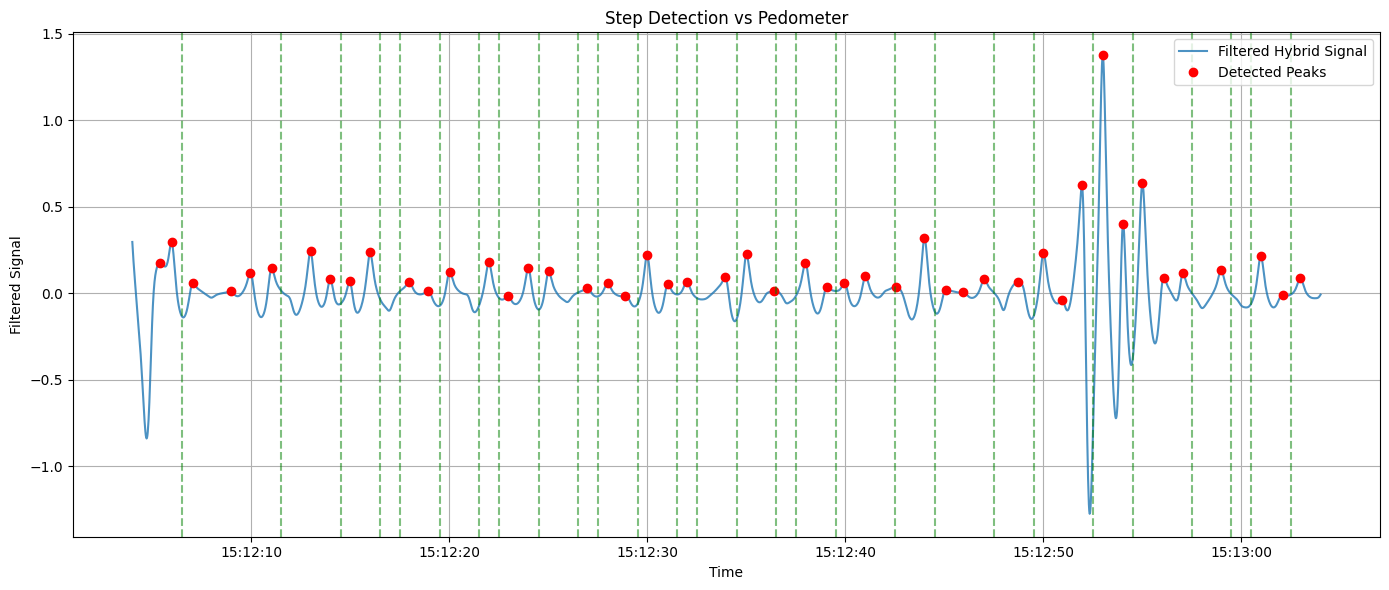

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# --- Load your resampled file ---
filename = '../data/kaggle-drdataboston/resampled_subjects/sub1-lw-s1.csv'
df = pd.read_csv(filename)
df['timestamp_50Hz'] = pd.to_datetime(df['timestamp_50Hz'])


# --- Reduce to first 60 seconds ---
start_time = df['timestamp_50Hz'].iloc[0]
end_time = start_time + pd.Timedelta(seconds=60)
df = df[df['timestamp_50Hz'] <= end_time]

# --- Sampling rate ---
fs = 50  # Hz

# --- Compute acceleration + gyro magnitude ---
acc_mag = np.sqrt(
    df['motionUserAccelerationX.G.']**2 +
    df['motionUserAccelerationY.G.']**2 +
    df['motionUserAccelerationZ.G.']**2
)
gyro_mag = np.sqrt(
    df['gyroRotationX.rad.s.']**2 +
    df['gyroRotationY.rad.s.']**2 +
    df['gyroRotationZ.rad.s.']**2
)

# --- Normalize both ---
acc_norm = (acc_mag - acc_mag.mean()) / acc_mag.std()
gyro_norm = (gyro_mag - gyro_mag.mean()) / gyro_mag.std()

# --- Combine ---
hybrid = 0.6 * acc_norm + 0.4 * gyro_norm

# --- Bandpass filter ---
lowcut, highcut = 0.5, 3.0
b, a = signal.butter(2, [lowcut / (fs/2), highcut / (fs/2)], btype='band')
hybrid_filt = signal.filtfilt(b, a, hybrid)

# --- Peak detection ---
peaks, _ = signal.find_peaks(hybrid_filt, distance=fs*0.4)

# --- Detect pedometer step increments ---
pedometer = df['pedometerNumberofSteps.N.'].fillna(method='ffill')
pedometer_diff = pedometer.diff().fillna(0)

step_change_indices = pedometer_diff[pedometer_diff > 0].index
step_change_times = df['timestamp_50Hz'].iloc[step_change_indices]

# --- Plot everything ---
plt.figure(figsize=(14, 6))
plt.plot(df['timestamp_50Hz'], hybrid_filt, label='Filtered Hybrid Signal', alpha=0.8)
plt.plot(df['timestamp_50Hz'].iloc[peaks], hybrid_filt[peaks], 'ro', label='Detected Peaks')

# Draw vertical lines at pedometer increments
for step_time in step_change_times:
    plt.axvline(x=step_time, color='green', linestyle='--', alpha=0.5)

plt.title('Step Detection vs Pedometer')
plt.xlabel('Time')
plt.ylabel('Filtered Signal')
plt.legend(loc='upper right')
plt.tight_layout()
plt.grid(True)
plt.show()
